In [28]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv("Dataset.csv")

In [32]:
df = df.drop(['Restaurant ID', 'Restaurant Name'], axis=1)

In [34]:
df = df.dropna()

In [36]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [38]:
X = df.drop('Aggregate rating', axis=1)
y = df['Aggregate rating']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [44]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [46]:
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)

print("Linear Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

print("\nDecision Tree:")
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("R2:", r2_score(y_test, y_pred_dt))

Linear Regression:
MSE: 1.1991823268674846
R2: 0.47634695867119026

Decision Tree:
MSE: 0.055468831849135654
R2: 0.9757781432848235


In [48]:
feature_importance = pd.Series(dt.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance)

Votes                   0.900065
Rating color            0.086267
Rating text             0.002563
Longitude               0.002216
Latitude                0.001895
Address                 0.001807
Cuisines                0.001735
Average Cost for two    0.001361
Locality Verbose        0.000687
Locality                0.000607
Has Online delivery     0.000308
City                    0.000198
Price range             0.000139
Has Table booking       0.000077
Country Code            0.000029
Is delivering now       0.000025
Currency                0.000021
Switch to order menu    0.000000
dtype: float64


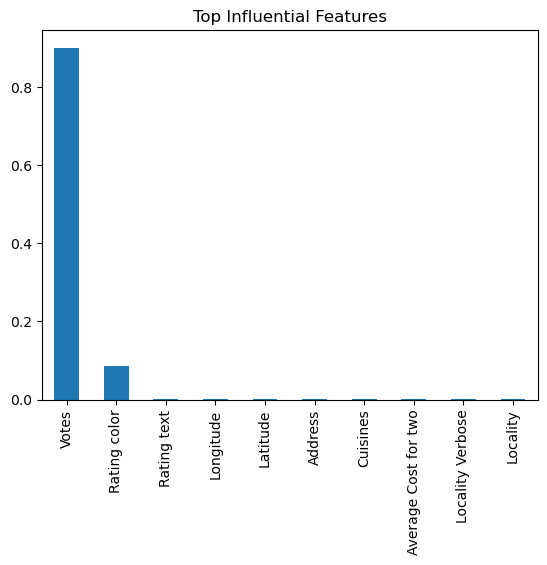

In [50]:
feature_importance.head(10).plot(kind='bar')
plt.title("Top Influential Features")
plt.show()